Treino shape: (33474, 26)
Distribuição target no treino:
target
1    0.515176
0    0.484824
Name: proportion, dtype: float64

Teste shape: (17907, 1)
Result shape: (17907, 1)

Distribuição das predições no teste:
count    17907.000000
mean         0.546420
std          0.490162
min          0.000000
25%          0.000000
50%          0.970000
75%          1.000000
max          1.000000
Name: target, dtype: float64
Processando test.csv...
Test features shape: (17907, 18)
Colunas: ['length', 'n_keydown', 'n_keyup', 'n_unique_codes', 'total_time', 'first_tick', 'hold_mean', 'hold_std', 'hold_median', 'hold_cv', 'flight_mean', 'flight_std', 'flight_median', 'flight_cv', 'press_press_mean', 'press_press_cv', 'keys_per_second', 'predicted']


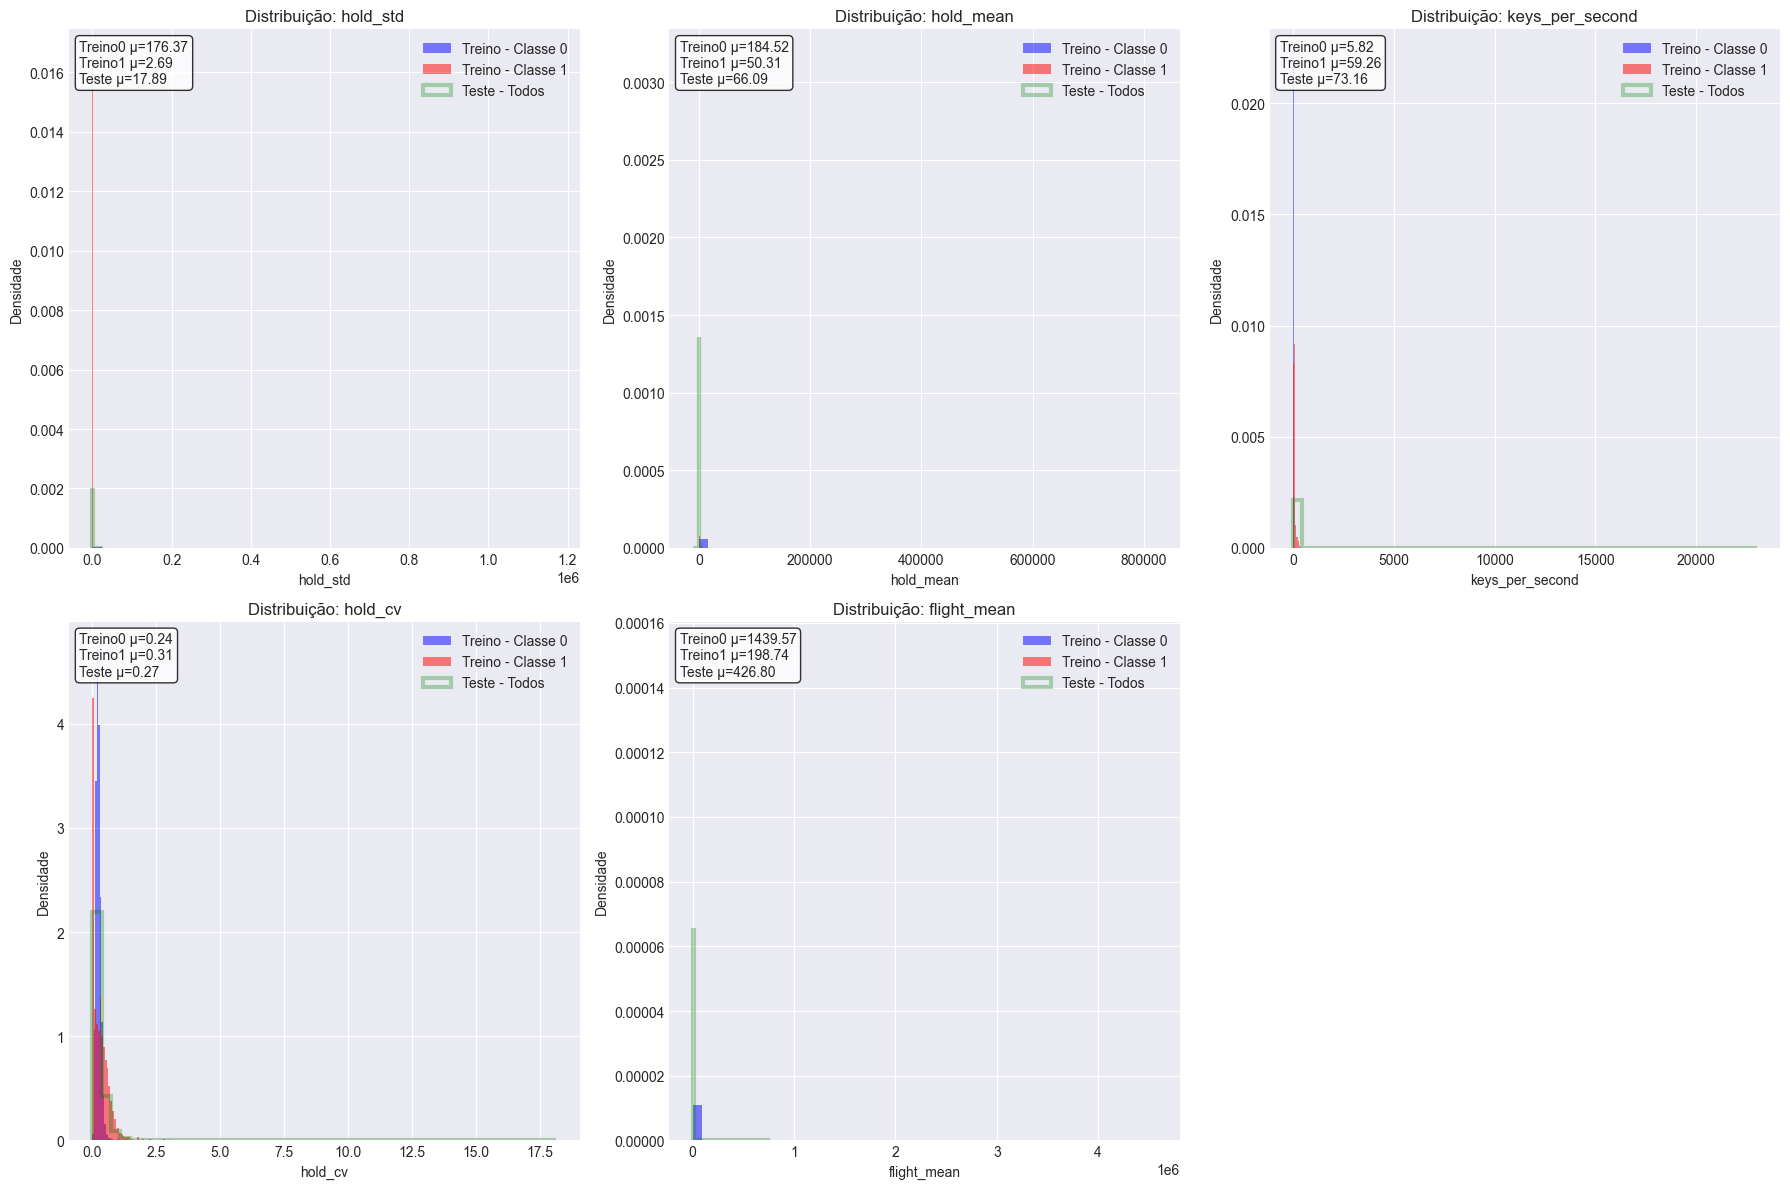

Análise de Drift (mudança nas distribuições):
           feature  train_mean   test_mean  drift_std  drift_percent
0         hold_std   86.896263   17.889298   0.008349     -79.413041
1        hold_mean  115.377394   66.092177   0.009982     -42.716528
2  keys_per_second   33.352331   73.158814   0.631794     119.351425
3          hold_cv    0.279022    0.265172   0.052225      -4.963726
4      flight_mean  800.322252  426.795229   0.009235     -46.672078

Predições por faixa de hold_mean:
                mean  count       std
hold_faixa                           
0-50ms      0.994045   7567  0.049306
50-100ms    0.022166   3883  0.135399
100-150ms   0.020162   3891  0.133415
150-200ms   0.211928    389  0.404560
200-300ms   0.864094    149  0.330485
300+ms      0.976130    460  0.150700

Relação hold_mean vs target no TREINO:
              mean          std
target                         
0       184.516020  7087.800282
1        50.312114   191.059536

Predições no TESTE por faixa de 

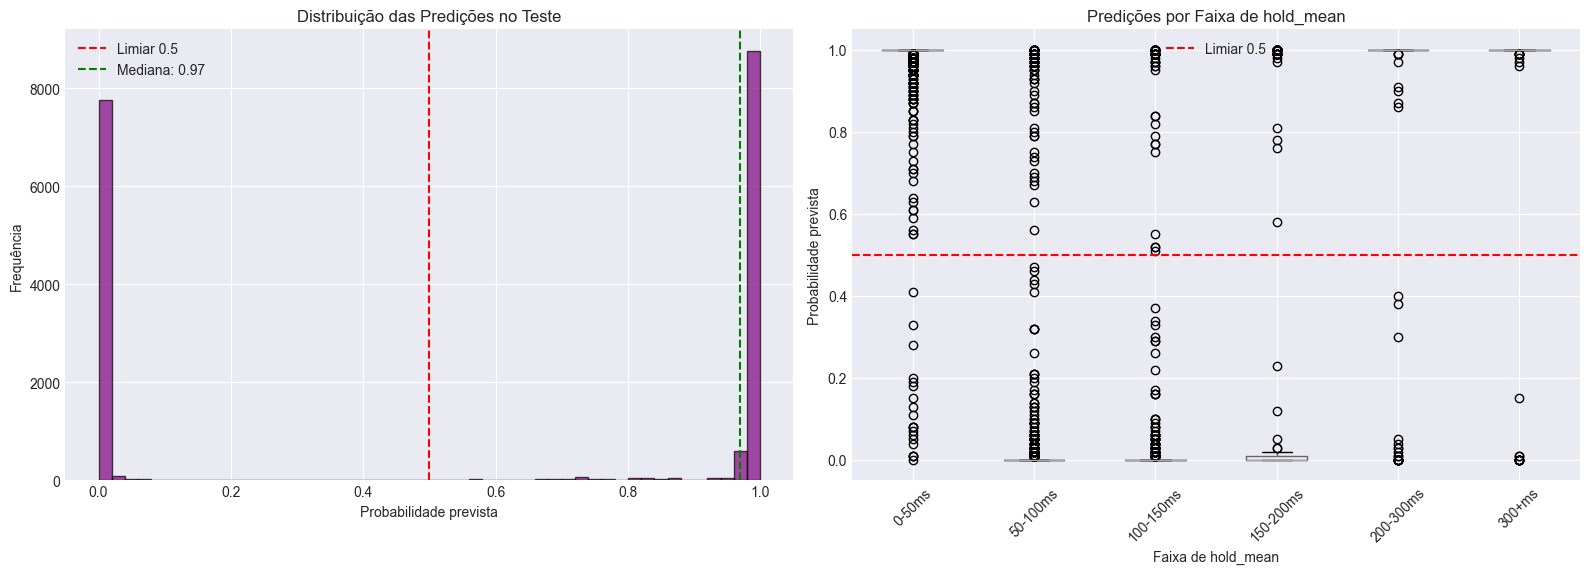


CONCLUSÃO DA ANÁLISE
Proporção de predições com alta confiança para classe 1 (>0.9): 52.77%
Proporção de predições com alta confiança para classe 0 (<0.1): 44.25%
Proporção de predições na região de dúvida (0.1-0.9): 2.99%

Hold mean no teste: 66.09 ms
Hold mean no treino (classe 0): 184.52 ms
Hold mean no treino (classe 1): 50.31 ms
✅ O hold mean do teste está MAIS PRÓXIMO da classe 1 - faz sentido ter mais predições como 1

Linhas sem keyup (hold_mean=0): 1498
Média das predições nessas linhas: 0.9291


In [ ]:

# # Model Drift - Análise Comparativa: Treino vs Teste
# Verificando se a distribuição das features no teste é consistente com o treino.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Configuração
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (14, 8)


#1. Carregar dados
# Carregar features do treino
df_train_features = pd.read_csv('../data/features_train.csv')
print(f"Treino shape: {df_train_features.shape}")
print(f"Distribuição target no treino:\n{df_train_features['target'].value_counts(normalize=True)}")

# Carregar modelo e predictions
model = joblib.load('../src/models/random_forest_final.pkl')
feature_names = joblib.load('../src/models/feature_names.pkl')

# Carregar test.csv original e result.csv
df_test_original = pd.read_csv('../data/test.csv')
df_result = pd.read_csv('../data/result.csv')

print(f"\nTeste shape: {df_test_original.shape}")
print(f"Result shape: {df_result.shape}")
print(f"\nDistribuição das predições no teste:")
print(df_result['target'].describe())

#2. Processar test.csv para extrair features

# Reaproveitar função de extração (copiado do script 02. )
import ast
from collections import defaultdict

def parse_inputs(inputs_series):
    return inputs_series.apply(ast.literal_eval)

def extract_features_for_analysis(df):
    """Análise (sem logging)"""
    features = []
    
    for idx, row in df.iterrows():
        try:
            data = row['inputs_parsed']
            keyboard_data = data.get('keyboard', {})
            keydown = keyboard_data.get('keydown', [])
            keyup = keyboard_data.get('keyup', [])
            
            feat = {}
            
            # Features básicas
            feat['length'] = data.get('length', len(keydown))
            feat['n_keydown'] = len(keydown)
            feat['n_keyup'] = len(keyup)
            feat['n_unique_codes'] = len(set([e['code'] for e in keydown])) if keydown else 0
            
            # Tempos totais
            if keydown:
                max_keydown = max(e['tick'] for e in keydown)
                min_keydown = min(e['tick'] for e in keydown)
            else:
                max_keydown = 0
                min_keydown = 0
                
            if keyup:
                max_keyup = max(e['tick'] for e in keyup)
            else:
                max_keyup = 0
            
            feat['total_time'] = max(max_keyup, max_keydown)
            feat['first_tick'] = min_keydown if keydown else 0
            
            # Hold times
            hold_times = []
            if keydown and keyup:
                keydown_queue = defaultdict(list)
                for event in sorted(keydown, key=lambda x: x['tick']):
                    keydown_queue[event['code']].append(event['tick'])
                for event in sorted(keyup, key=lambda x: x['tick']):
                    code = event['code']
                    if keydown_queue[code]:
                        press_time = keydown_queue[code].pop(0)
                        hold_time = event['tick'] - press_time
                        hold_times.append(hold_time)
            
            if hold_times:
                feat['hold_mean'] = np.mean(hold_times)
                feat['hold_std'] = np.std(hold_times)
                feat['hold_median'] = np.median(hold_times)
                feat['hold_cv'] = feat['hold_std'] / feat['hold_mean'] if feat['hold_mean'] > 0 else 0
            else:
                feat['hold_mean'] = 0
                feat['hold_std'] = 0
                feat['hold_median'] = 0
                feat['hold_cv'] = 0
            
            # Flight times
            all_events = []
            for e in keydown:
                all_events.append(('down', e['code'], e['tick']))
            for e in keyup:
                all_events.append(('up', e['code'], e['tick']))
            
            flight_times = []
            if len(all_events) > 1:
                all_events.sort(key=lambda x: x[2])
                for i in range(1, len(all_events)):
                    flight_times.append(all_events[i][2] - all_events[i-1][2])
            
            if flight_times:
                feat['flight_mean'] = np.mean(flight_times)
                feat['flight_std'] = np.std(flight_times)
                feat['flight_median'] = np.median(flight_times)
                feat['flight_cv'] = feat['flight_std'] / feat['flight_mean'] if feat['flight_mean'] > 0 else 0
            else:
                feat['flight_mean'] = 0
                feat['flight_std'] = 0
                feat['flight_median'] = 0
                feat['flight_cv'] = 0
            
            # Press-press
            press_press = []
            if len(keydown) > 1:
                keydown_times = [e['tick'] for e in sorted(keydown, key=lambda x: x['tick'])]
                for i in range(1, len(keydown_times)):
                    press_press.append(keydown_times[i] - keydown_times[i-1])
            
            if press_press:
                feat['press_press_mean'] = np.mean(press_press)
                feat['press_press_cv'] = np.std(press_press) / np.mean(press_press) if np.mean(press_press) > 0 else 0
            else:
                feat['press_press_mean'] = 0
                feat['press_press_cv'] = 0
            
            # Velocidade
            if feat['total_time'] > 0:
                feat['keys_per_second'] = feat['n_keydown'] / (feat['total_time'] / 1000)
            else:
                feat['keys_per_second'] = 0
            
            features.append(feat)
            
        except Exception:
            # Em erro, adicionar zeros
            feat = {k: 0 for k in ['length', 'n_keydown', 'n_keyup', 'n_unique_codes',
                                   'total_time', 'first_tick', 'hold_mean', 'hold_std',
                                   'hold_median', 'hold_cv', 'flight_mean', 'flight_std',
                                   'flight_median', 'flight_cv', 'press_press_mean',
                                   'press_press_cv', 'keys_per_second']}
            features.append(feat)
    
    return pd.DataFrame(features)

print("Processando test.csv")
df_test_original['inputs_parsed'] = parse_inputs(df_test_original['inputs'])
df_test_features = extract_features_for_analysis(df_test_original)
df_test_features['predicted'] = df_result['target']

print(f"Test features shape: {df_test_features.shape}")
print(f"Colunas: {df_test_features.columns.tolist()}")


#3. Comparar distribuições das principais features
# Features mais importantes (segundo o modelo)
top_features = ['hold_std', 'hold_mean', 'keys_per_second', 'hold_cv', 'flight_mean']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    ax = axes[i]
    
    # Dados do treino (separados por classe)
    train_0 = df_train_features[df_train_features['target'] == 0][feature].dropna()
    train_1 = df_train_features[df_train_features['target'] == 1][feature].dropna()
    
    # Dados do teste (todos)
    test_all = df_test_features[feature].dropna()
    
    # Plotar
    ax.hist(train_0, bins=50, alpha=0.5, label='Treino - Classe 0', density=True, color='blue')
    ax.hist(train_1, bins=50, alpha=0.5, label='Treino - Classe 1', density=True, color='red')
    ax.hist(test_all, bins=50, alpha=0.3, label='Teste - Todos', density=True, color='green', histtype='step', linewidth=3)
    
    ax.set_xlabel(feature)
    ax.set_ylabel('Densidade')
    ax.set_title(f'Distribuição: {feature}')
    ax.legend()
    
    # Estatísticas
    ax.text(0.02, 0.98, f'Treino0 μ={train_0.mean():.2f}\nTreino1 μ={train_1.mean():.2f}\nTeste μ={test_all.mean():.2f}', 
            transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Remover subplot extra
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()


#4. Análise de drift (mudança nas distribuições?)
drift_analysis = []

for feature in top_features:
    train_mean = df_train_features[feature].mean()
    train_std = df_train_features[feature].std()
    test_mean = df_test_features[feature].mean()
    
    # Calcular drift em desvios padrão
    drift_std = abs(test_mean - train_mean) / train_std if train_std > 0 else 0
    
    drift_analysis.append({
        'feature': feature,
        'train_mean': train_mean,
        'test_mean': test_mean,
        'drift_std': drift_std,
        'drift_percent': (test_mean - train_mean) / train_mean * 100 if train_mean != 0 else 0
    })

df_drift = pd.DataFrame(drift_analysis)
print("Análise de Drift (mudança nas distribuições):")
print(df_drift.to_string())


#5. Analisar as predições por faixa de hold_mean

# Criar faixas de hold_mean
df_test_features['hold_faixa'] = pd.cut(df_test_features['hold_mean'], 
                                        bins=[0, 50, 100, 150, 200, 300, 1000],
                                        labels=['0-50ms', '50-100ms', '100-150ms', 
                                                '150-200ms', '200-300ms', '300+ms'])

print("\nPredições por faixa de hold_mean:")
print("="*60)
faixa_stats = df_test_features.groupby('hold_faixa')['predicted'].agg(['mean', 'count', 'std'])
print(faixa_stats)


# ## 6. Comparar com o que esperaríamos do treino
# No treino, qual a relação entre hold_mean e target?
train_hold_by_target = df_train_features.groupby('target')['hold_mean'].agg(['mean', 'std'])
print("\nRelação hold_mean vs target no TREINO:")
print(train_hold_by_target)

# No teste, como estão as predições?
print("\nPredições no TESTE por faixa de hold_mean (esperado vs real):")
print("Hold time baixo (<100ms) deve ser classe 1, alto (>150ms) deve ser classe 0")
print(faixa_stats[['mean', 'count']])


#7. Visualizar distribuição das predições
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma das predições
ax = axes[0]
ax.hist(df_test_features['predicted'], bins=50, edgecolor='black', alpha=0.7, color='purple')
ax.axvline(x=0.5, color='red', linestyle='--', label='Limiar 0.5')
ax.axvline(x=df_test_features['predicted'].median(), color='green', linestyle='--', 
           label=f'Mediana: {df_test_features["predicted"].median():.2f}')
ax.set_xlabel('Probabilidade prevista')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição das Predições no Teste')
ax.legend()

# Boxplot das predições por faixa de hold_mean
ax = axes[1]
df_test_features.boxplot(column='predicted', by='hold_faixa', ax=ax, rot=45)
ax.set_xlabel('Faixa de hold_mean')
ax.set_ylabel('Probabilidade prevista')
ax.set_title('Predições por Faixa de hold_mean')
ax.axhline(y=0.5, color='red', linestyle='--', label='Limiar 0.5')
ax.legend()

plt.suptitle('')
plt.tight_layout()
plt.show()


#8. Conclusão da análise
# Calcular proporção de amostras com alta probabilidade
high_conf_1 = (df_test_features['predicted'] > 0.9).mean()
high_conf_0 = (df_test_features['predicted'] < 0.1).mean()
mid_conf = ((df_test_features['predicted'] >= 0.1) & (df_test_features['predicted'] <= 0.9)).mean()

print("\n" + "="*60)
print("CONCLUSÃO DA ANÁLISE")
print("="*60)
print(f"Proporção de predições com alta confiança para classe 1 (>0.9): {high_conf_1:.2%}")
print(f"Proporção de predições com alta confiança para classe 0 (<0.1): {high_conf_0:.2%}")
print(f"Proporção de predições na região de dúvida (0.1-0.9): {mid_conf:.2%}")

# Verificar se hold_mean do teste é consistente
test_hold_mean = df_test_features['hold_mean'].mean()
train_hold_mean_0 = train_hold_by_target.loc[0, 'mean']
train_hold_mean_1 = train_hold_by_target.loc[1, 'mean']

print(f"\nHold mean no teste: {test_hold_mean:.2f} ms")
print(f"Hold mean no treino (classe 0): {train_hold_mean_0:.2f} ms")
print(f"Hold mean no treino (classe 1): {train_hold_mean_1:.2f} ms")

if abs(test_hold_mean - train_hold_mean_1) < abs(test_hold_mean - train_hold_mean_0):
    print("✅ O hold mean do teste está MAIS PRÓXIMO da classe 1 - faz sentido ter mais predições como 1")
else:
    print("⚠️ O hold mean do teste está mais próximo da classe 0 - investigar por que modelo está prevendo classe 1")


#9. Verificar linhas sem keyup

linhas_sem_keyup = df_test_features[df_test_features['hold_mean'] == 0].shape[0]
print(f"\nLinhas sem keyup (hold_mean=0): {linhas_sem_keyup}")
if linhas_sem_keyup > 0:
    pred_sem_keyup = df_test_features[df_test_features['hold_mean'] == 0]['predicted'].mean()
    print(f"Média das predições nessas linhas: {pred_sem_keyup:.4f}")